# Proyek Klasifikasi Gambar: [Vehicle](https://www.kaggle.com/datasets/yash88600/miotcd-dataset-50000-imagesclassification/data?select=train1)
- **Nama:** Mohammad Raihan Hadriansyah Prasetya
- **Email:** raihanhadriansyah111@gmail.com
- **ID Dicoding:** CACC012D6Y2075

## Import Semua Packages/Library yang Digunakan





In [1]:
# 1. Menghubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Mengimpor semua library yang dibutuhkan (Sesuai gaya mentor, tanpa Tkinter)
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
import shutil

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image

# Library untuk menyimpan model ke TFJS
#!pip install tensorflowjs -q
import tensorflowjs as tfjs

print("\nSemua library berhasil diimpor!")
print("Versi TensorFlow:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Semua library berhasil diimpor!
Versi TensorFlow: 2.19.0


## Data Preparation

###Data Loading

✅ Folder utama berhasil ditemukan!

--- Rincian Data Per Kelas ---
Total Data Car         : 6268 gambar
Total Data Bus         : 5102 gambar
Total Data Truck       : 4991 gambar
Total Data Motorcycle  : 1993 gambar
-----------------------------------
Total keseluruhan gambar (4 Kelas): 18354 gambar

Menampilkan Grafik Distribusi Dataset...


/tmp/ipykernel_11066/2516711084.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


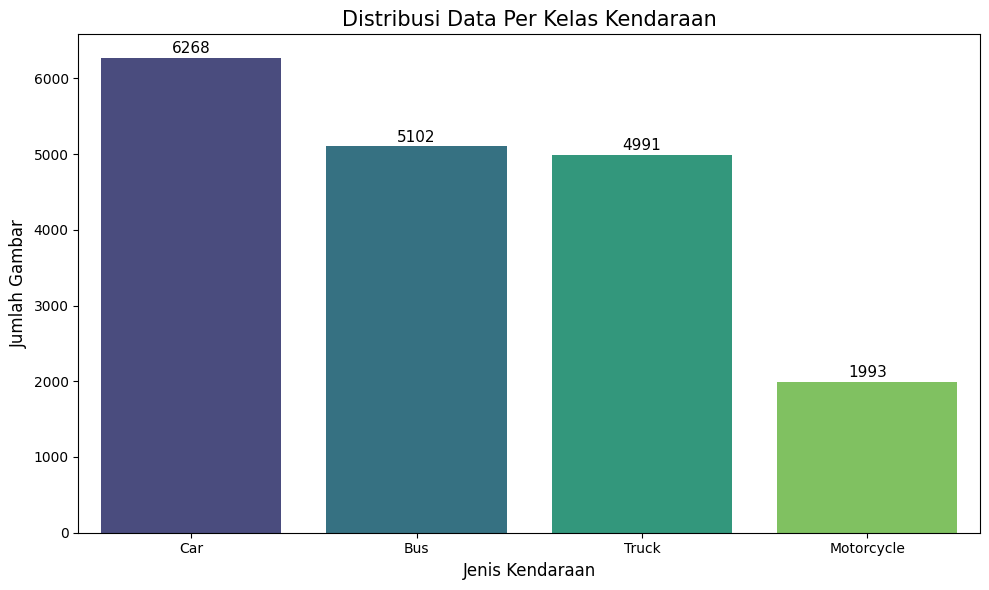

In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

dir_dataset = "/content/drive/MyDrive/Dataset Vehicle"

# 1. Mengecek apakah folder utama ada
if not os.path.exists(dir_dataset):
    print(f"⛔ ERROR: Folder '{dir_dataset}' tidak ditemukan!")
    print("💡 Berikut adalah daftar folder yang ada di Google Drive Anda saat ini. Silakan periksa ejaannya:")
    # Menampilkan isi MyDrive agar Anda bisa memastikan nama pastinya
    print(os.listdir("/content/drive/MyDrive/"))
else:
    print("✅ Folder utama berhasil ditemukan!\n")

    # Menyiapkan variabel untuk menampung total gambar dari 4 kelas
    total_4_kelas = 0
    classes = ['car', 'bus', 'truck', 'motorcycle']

    # --- TAMBAHAN: Variabel untuk menyimpan data visualisasi ---
    class_counts = {}

    print("--- Rincian Data Per Kelas ---")
    # 2. Menghitung rincian per kelas sekaligus mengakumulasi totalnya
    for cls in classes:
        dir_cls = os.path.join(dir_dataset, cls)
        if os.path.exists(dir_cls):
            total_file = len(os.listdir(dir_cls))
            total_4_kelas += total_file # Menambahkan ke total keseluruhan
            class_counts[cls.capitalize()] = total_file # Menyimpan jumlah untuk digambar
            print(f"Total Data {cls.capitalize():<12}: {total_file} gambar")
        else:
            class_counts[cls.capitalize()] = 0 # Menyimpan 0 jika folder tidak ada
            print(f"Total Data {cls.capitalize():<12}: 0 (Subfolder '{cls}' tidak ditemukan)")

    # 3. Menampilkan total dari penjumlahan 4 kelas
    print("-" * 35)
    print(f"Total keseluruhan gambar (4 Kelas): {total_4_kelas} gambar\n")

    # --- TAMBAHAN: Visualisasi Distribusi Dataset ---
    print("Menampilkan Grafik Distribusi Dataset...")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
    plt.title('Distribusi Data Per Kelas Kendaraan', fontsize=15)
    plt.xlabel('Jenis Kendaraan', fontsize=12)
    plt.ylabel('Jumlah Gambar', fontsize=12)

    # Menambahkan label angka pas di atas masing-masing tiang (bar)
    for i, val in enumerate(class_counts.values()):
        plt.text(i, val + (max(class_counts.values()) * 0.01), str(val), ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()

## Data Preprocessing

### Split Dataset

In [5]:
# 1. Mengumpulkan path gambar HANYA dari 4 kelas yang diinginkan
dir_dataset = "/content/drive/MyDrive/Dataset Vehicle"
kelas_diinginkan = ['car', 'bus', 'truck', 'motorcycle']

all_images = []
for cls in kelas_diinginkan:
    # Mengambil semua file di dalam masing-masing folder kelas
    all_images.extend(glob.glob(os.path.join(dir_dataset, cls, '*.*')))

print(f"Berhasil mengumpulkan {len(all_images)} path gambar untuk diproses.")

# 2. Menyiapkan DataFrame
labels = [os.path.basename(os.path.dirname(path)) for path in all_images]
df = pd.DataFrame({'filename': all_images, 'label': labels})

# 3. Split Dataset (80% Train, 10% Val, 10% Test)
# Membagi 80% Train, 20% sisa
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
# Membagi sisa 20% menjadi 10% Val dan 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Jumlah Data -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# 4. Menyiapkan ImageDataGenerator & Augmentasi
img_height, img_width = 224, 224
batch_size = 32

# Augmentasi KHUSUS untuk Train Set
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Test dan Val Set TIDAK BOLEH di-augmentasi
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 5. Memuat Data ke Generator
print("\nMenyiapkan Data Generator...")
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='label',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='label',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='label',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Berhasil mengumpulkan 18354 path gambar untuk diproses.
Jumlah Data -> Train: 14683 | Val: 1835 | Test: 1836

Menyiapkan Data Generator...
Found 14683 validated image filenames belonging to 4 classes.
Found 1835 validated image filenames belonging to 4 classes.
Found 1836 validated image filenames belonging to 4 classes.


## Modelling

In [6]:
# 1. Mengunduh MobileNetV2 sebagai Feature Extractor (Tanpa layer klasifikasi di atasnya)
base_model = MobileNetV2(input_shape=(img_height, img_width, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False # Kunci agar bobot pre-trained tidak rusak saat awal latihan

# 2. Membangun Arsitektur Sequential
model = models.Sequential([
    base_model,

    # Menambahkan Conv2D dan MaxPooling2D
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Mengubah fitur 2D menjadi 1D
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layer dengan Dropout untuk mencegah overfitting
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Layer Output (4 Kelas kendaraan dengan aktivasi softmax)
    layers.Dense(len(kelas_diinginkan), activation='softmax')
])

# 3. Kompilasi Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Ringkasan Arsitektur Model ---")
model.summary()

# 4. Menyiapkan Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# 5. Memulai Pelatihan (Training)
print("\nMemulai Pelatihan Model... (Ini mungkin memakan waktu beberapa saat)")
epochs = 20 # Maksimal 20 epoch, bisa berhenti lebih cepat karena EarlyStopping

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# 6. Menampilkan Hasil Akhir Pelatihan
print("\n--- Hasil Pelatihan Terakhir ---")
print("Akurasi Training Akhir: {:.2f}%".format(history.history['accuracy'][-1] * 100))
print("Loss Training Akhir   : {:.4f}".format(history.history['loss'][-1]))
print("Akurasi Val Akhir     : {:.2f}%".format(history.history['val_accuracy'][-1] * 100))
print("Loss Val Akhir        : {:.4f}".format(history.history['val_loss'][-1]))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- Ringkasan Arsitektur Model ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,653,988 (10.12 MB)

 Trainable params: 396,004 (1.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Memulai Pelatihan Model... (Ini mungkin memakan waktu beberapa saat)
Epoch 1/20
459/459 ━━━━━━━━━━━━━━━━━━━━ 10696s 23s/step - accuracy: 0.8118 - loss: 0.5191 - val_accuracy: 0.9030 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 2/20
459/459 ━━━━━━━━━━━━━━━━━━━━ 225s 490ms/step - accuracy: 0.8957 - loss: 0.3035 - val_accuracy: 0.8992 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 3/20
459/459 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9049 - loss: 0.2815
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
459/459 ━━━━━━━━━━━━━━━━━━━━ 225s 490ms/step - accuracy: 0.9098 - loss: 0.2684 - val_accuracy: 0.8834 - val_loss: 0.3569 - learning_rate: 0.0010
Epoch 4/20
459/459 ━━━━━━━━━━━━━━━━━━━━ 230s 501ms/step - accuracy: 0.9282 - loss: 0.2111 - val_accuracy: 0.9259 - val_loss: 0.2081 - learning_rate: 5.0000e-04
Epoch 5/20
459/459 ━━━━━━━━━━━━━━━━━━━━ 229s 498ms/step - accuracy: 0.9341 - loss: 0.1894 - val_accuracy: 0.9248 - val_loss: 0.2170 - learning_rate: 

## Evaluasi dan Visualisasi

58/58 ━━━━━━━━━━━━━━━━━━━━ 1152s 20s/step - accuracy: 0.9346 - loss: 0.1906

Akurasi pada test set: 93.46%
Loss pada test set: 0.1906


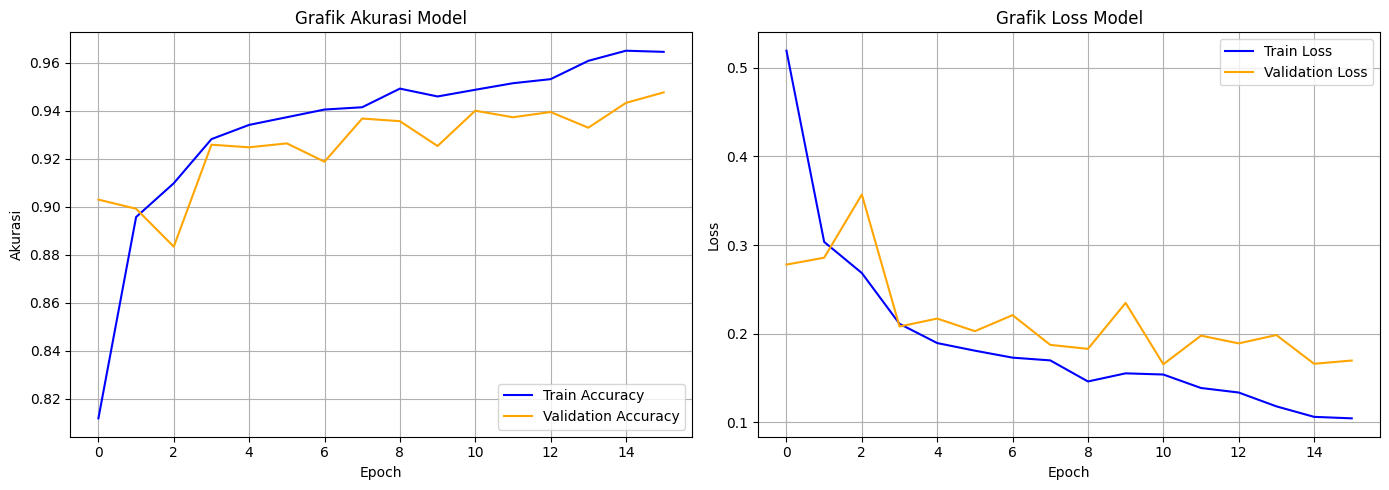

In [7]:
# 1. Evaluasi pada Test Set (Data yang belum pernah dilihat model sama sekali)
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"\nAkurasi pada test set: {test_accuracy * 100:.2f}%")
print(f"Loss pada test set: {test_loss:.4f}")

# 2. Membuat Plot Akurasi dan Loss
plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step


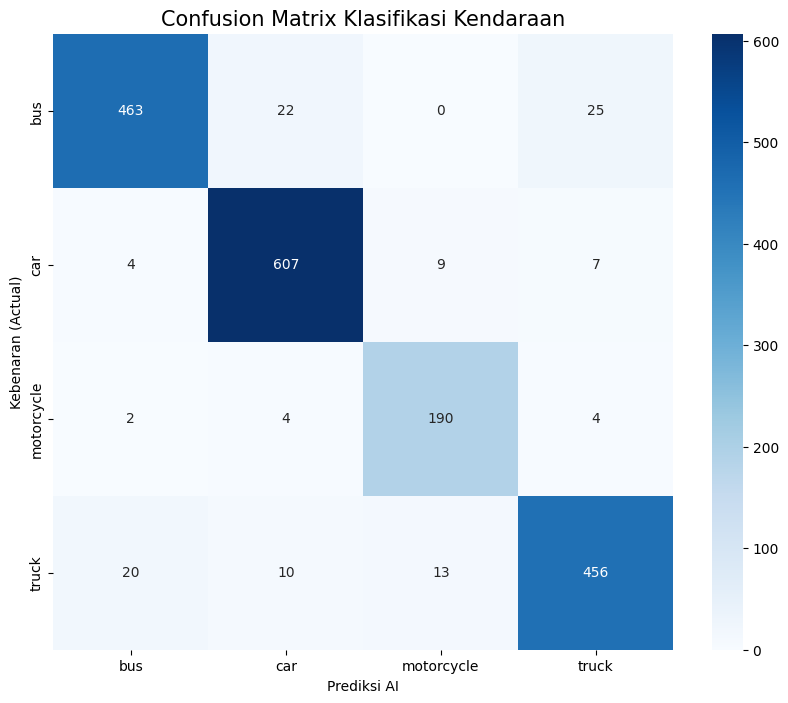


Classification Report:

              precision    recall  f1-score   support

         bus       0.95      0.91      0.93       510
         car       0.94      0.97      0.96       627
  motorcycle       0.90      0.95      0.92       200
       truck       0.93      0.91      0.92       499

    accuracy                           0.93      1836
   macro avg       0.93      0.93      0.93      1836
weighted avg       0.93      0.93      0.93      1836



In [15]:
# --- Membuat Confusion Matrix ---

# 1. Ambil prediksi dari test_gen
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

# 2. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
target_names = list(test_gen.class_indices.keys())

# 3. Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix Klasifikasi Kendaraan', fontsize=15)
plt.ylabel('Kebenaran (Actual)')
plt.xlabel('Prediksi AI')
plt.show()

# Tambahan: Print Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

## Konversi Model


In [16]:
# 1. Simpan dalam format SavedModel
model.export('saved_model')
print("✅ 1. Model berhasil disimpan dalam format TensorFlow SavedModel.")

# 2. Simpan dalam format TFJS
# Memastikan folder tfjs_model siap
tfjs.converters.save_keras_model(model, 'tfjs_model')
print("✅ 2. Model berhasil disimpan dalam format TensorFlow.js.")

# 3. Simpan dalam format TF-Lite
if not os.path.exists('tflite'):
    os.makedirs('tflite')

converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()

with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ 3. Model berhasil disimpan dalam format TensorFlow Lite.")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133848473208592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473214352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473212240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473208016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473214928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473215120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473213584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473215696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473215312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473213200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133848473213776

✅ 1. Model berhasil disimpan dalam format TensorFlow SavedModel.
failed to lookup keras version from the file,
    this is likely a weight only file
✅ 2. Model berhasil disimpan dalam format TensorFlow.js.
✅ 3. Model berhasil disimpan dalam format TensorFlow Lite.


## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


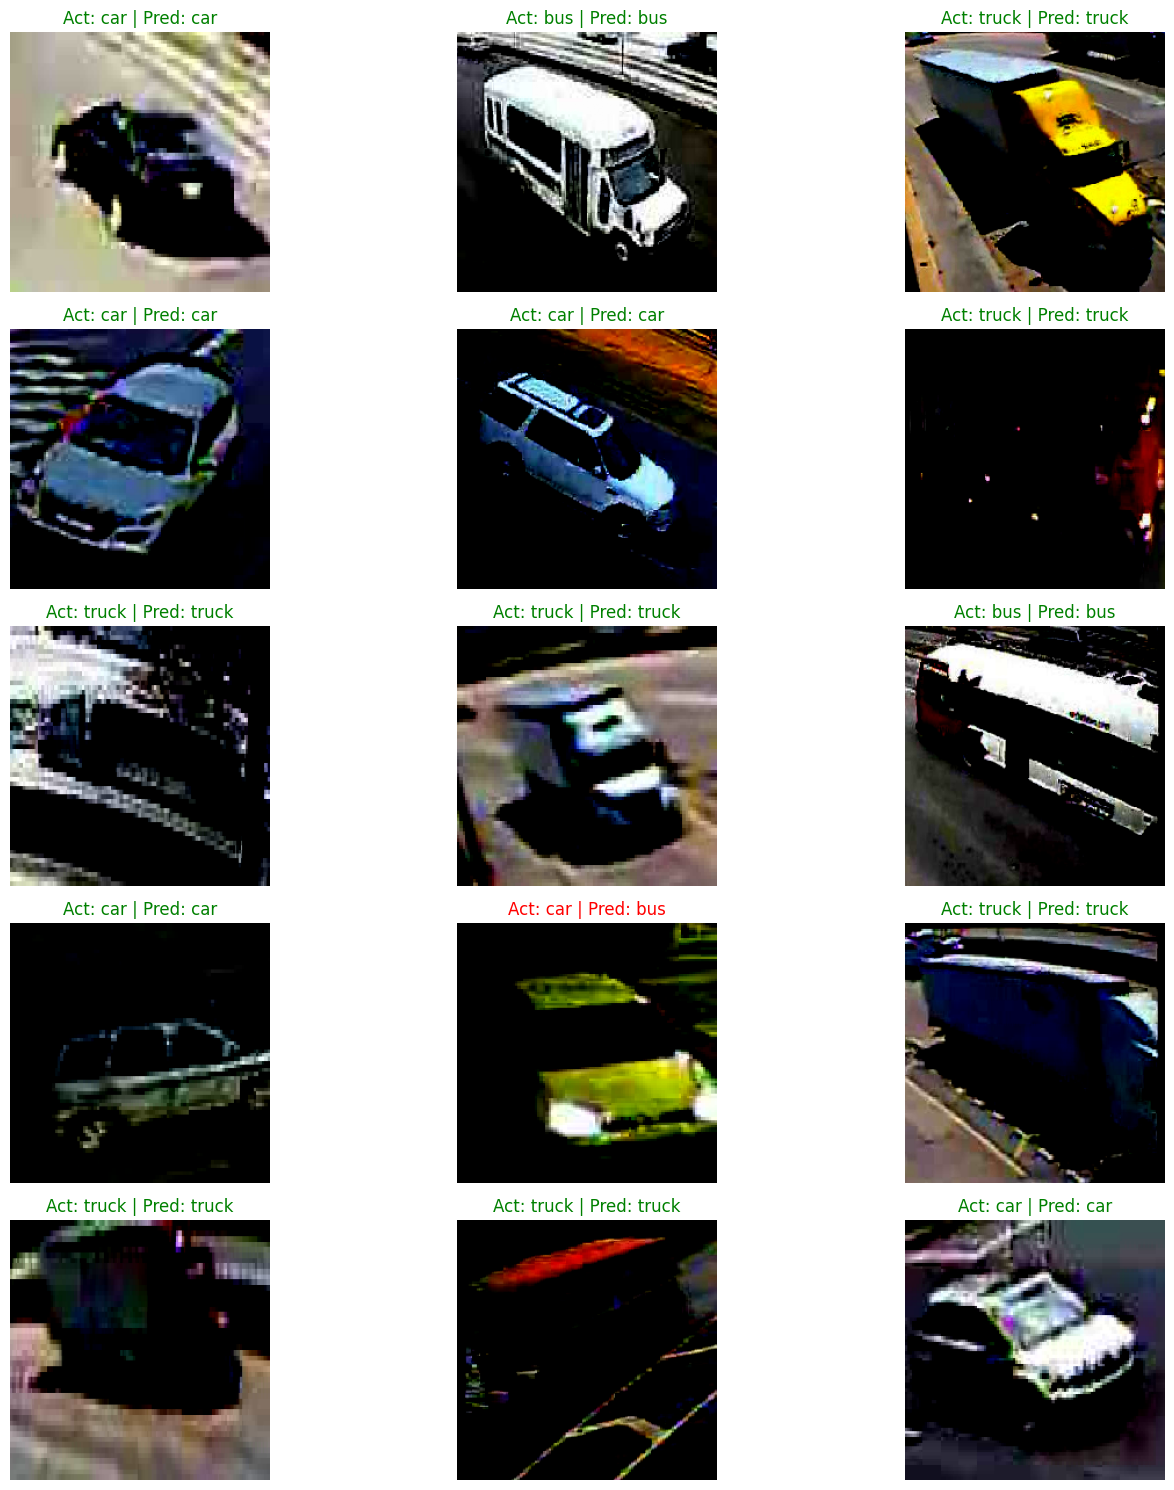

In [17]:
# --- Sample Prediction Grid (Visualisasi Hasil Tes) ---
plt.figure(figsize=(15, 15))

# Mengambil 1 batch data dari test_gen
images, labels = next(test_gen)
predictions = model.predict(images)

for i in range(15):
    plt.subplot(5, 3, i + 1)
    plt.imshow(images[i])

    actual = target_names[np.argmax(labels[i])]
    predicted = target_names[np.argmax(predictions[i])]

    color = 'green' if actual == predicted else 'red'

    plt.title(f"Act: {actual} | Pred: {predicted}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

Model mengenali kelas berikut: ['bus', 'car', 'motorcycle', 'truck']

Silakan unggah gambar kendaraan (Mobil, Motor, Bus, atau Truk):


Saving mustang.webp to mustang.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


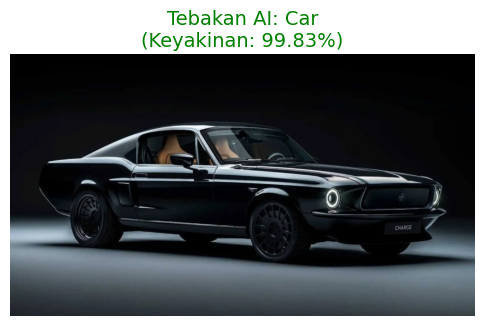

In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.image as mpimg

%matplotlib inline

# Mengambil daftar nama kelas langsung dari generator
class_names = list(train_gen.class_indices.keys())
print(f"Model mengenali kelas berikut: {class_names}\n")

print("Silakan unggah gambar kendaraan (Mobil, Motor, Bus, atau Truk):")
uploaded = files.upload()

for fn in uploaded.keys():
    # Load dan Tampilkan Gambar
    path = fn
    img_show = mpimg.imread(path)

    # Preprocessing gambar agar sesuai format saat training
    img = image.load_img(path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array) # Wajib karena kita pakai MobileNetV2

    # Melakukan Prediksi
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions) * 100

    # Menampilkan hasil visual
    plt.figure(figsize=(6, 6))
    plt.imshow(img_show)
    plt.axis('off')
    plt.title(f"Tebakan AI: {predicted_class.capitalize()}\n(Keyakinan: {confidence:.2f}%)", fontsize=14, color='green')
    plt.show()